In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import warnings
warnings.filterwarnings('ignore')

# Data Frame

In [2]:
accident = pd.read_csv('DATASETS\\accident_data.csv')

In [3]:
accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Index                    660679 non-null  object 
 1   Accident_Severity        660679 non-null  object 
 2   Accident Date            660679 non-null  object 
 3   Latitude                 660654 non-null  float64
 4   Light_Conditions         660679 non-null  object 
 5   District Area            660679 non-null  object 
 6   Longitude                660653 non-null  float64
 7   Number_of_Casualties     660679 non-null  int64  
 8   Number_of_Vehicles       660679 non-null  int64  
 9   Road_Surface_Conditions  659953 non-null  object 
 10  Road_Type                656159 non-null  object 
 11  Urban_or_Rural_Area      660664 non-null  object 
 12  Weather_Conditions       646551 non-null  object 
 13  Vehicle_Type             660679 non-null  object 
dtypes: f

In [4]:
accident['Latitude'] = accident['Latitude'].fillna(accident['Latitude'].mode()[0])
accident['Longitude'] = accident['Longitude'].fillna(accident['Longitude'].mode()[0])
accident['Road_Surface_Conditions'] = accident['Road_Surface_Conditions'].fillna(accident['Road_Surface_Conditions'].mode()[0])
accident['Road_Type'] = accident['Road_Type'].fillna(accident['Road_Type'].mode()[0])
accident['Weather_Conditions'] = accident['Weather_Conditions'].fillna(accident['Weather_Conditions'].mode()[0])
accident['Urban_or_Rural_Area'] = accident['Urban_or_Rural_Area'].fillna(accident['Urban_or_Rural_Area'].mode()[0])                                                                                         

In [5]:
accident['Accident Date'] = accident['Accident Date'].astype('str')
accident['Accident Date'] = accident['Accident Date'].str.strip()
accident['Accident Date'] = accident['Accident Date'].str.replace('/', '-')

# Convert Date 

In [6]:
accident['Accident Date'] = pd.to_datetime(accident['Accident Date'], dayfirst = True, errors = 'coerce')

In [7]:
accident['Year'] = accident['Accident Date'].dt.year
accident['Month'] = accident['Accident Date'].dt.month
accident['Day'] = accident['Accident Date'].dt.day
accident['DayOfWeek'] = accident['Accident Date'].dt.dayofweek

In [8]:
accident.isnull().sum()

Index                      0
Accident_Severity          0
Accident Date              0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
Year                       0
Month                      0
Day                        0
DayOfWeek                  0
dtype: int64

In [9]:
accident.dtypes

Index                              object
Accident_Severity                  object
Accident Date              datetime64[ns]
Latitude                          float64
Light_Conditions                   object
District Area                      object
Longitude                         float64
Number_of_Casualties                int64
Number_of_Vehicles                  int64
Road_Surface_Conditions            object
Road_Type                          object
Urban_or_Rural_Area                object
Weather_Conditions                 object
Vehicle_Type                       object
Year                                int32
Month                               int32
Day                                 int32
DayOfWeek                           int32
dtype: object

In [10]:
accident['Accident_Severity'] = accident['Accident_Severity'].astype('category')

In [11]:
accident['Light_Conditions'] = accident['Light_Conditions'].astype('category')

In [12]:
accident['District Area'] = accident['District Area'].astype('category')

In [13]:
accident['Number_of_Casualties'] = accident['Number_of_Casualties'].astype('category')

In [14]:
accident['Number_of_Vehicles'] = accident['Number_of_Vehicles'].astype('category')

In [15]:
accident['Road_Surface_Conditions'] = accident['Road_Surface_Conditions'].astype('category')

In [16]:
accident['Road_Type'] = accident['Road_Type'].astype('category')

In [17]:
accident['Urban_or_Rural_Area'] = accident['Urban_or_Rural_Area'].astype('category')

In [18]:
accident['Weather_Conditions'] = accident['Weather_Conditions'].astype('category')


In [19]:
accident['Accident_Severity'] = accident['Accident_Severity'].astype('category')

In [20]:
accident['Vehicle_Type'] = accident['Vehicle_Type'].astype('category')

In [21]:
accident['Latitude'] = accident['Latitude'].astype('category')

In [22]:
accident['Longitude'] = accident['Longitude'].astype('category')

In [23]:
accident['Year'] = accident['Year'].astype('category')


In [24]:
accident['Month'] = accident['Month'].astype('category')

In [25]:
accident['Day'] = accident['Day'].astype('category')

In [26]:
accident['DayOfWeek'] = accident['DayOfWeek'].astype('category')

In [27]:
accident.dtypes


Index                              object
Accident_Severity                category
Accident Date              datetime64[ns]
Latitude                         category
Light_Conditions                 category
District Area                    category
Longitude                        category
Number_of_Casualties             category
Number_of_Vehicles               category
Road_Surface_Conditions          category
Road_Type                        category
Urban_or_Rural_Area              category
Weather_Conditions               category
Vehicle_Type                     category
Year                             category
Month                            category
Day                              category
DayOfWeek                        category
dtype: object

# #1 What date has a more accident rate ?

In [28]:
accident['Accident Date'].mode()[0]


Timestamp('2019-11-30 00:00:00')

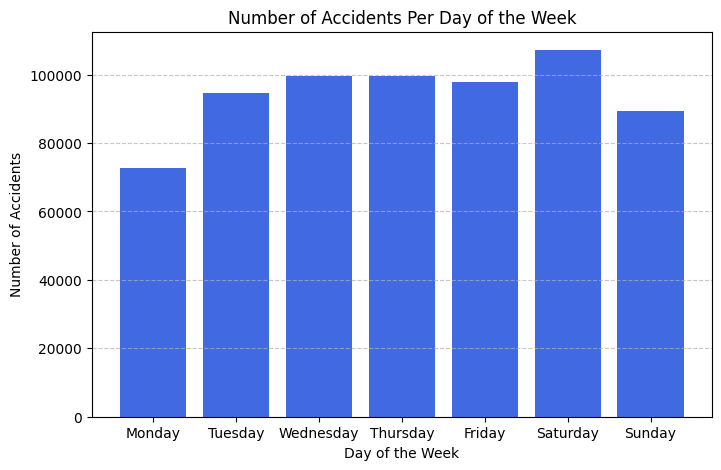

In [29]:
accident['Day'] = accident['Accident Date'].dt.day_name()

# Count accidents per day of the week
accident_counts = accident['Day'].value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(accident_counts.index, accident_counts.values, color='Royalblue')

plt.xlabel("Day of the Week")
plt.ylabel("Number of Accidents")
plt.title("Number of Accidents Per Day of the Week")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# INSIGTH#1

# Most accident happens on 2021-02-11


# #2 What district is commonly involve in accidents?

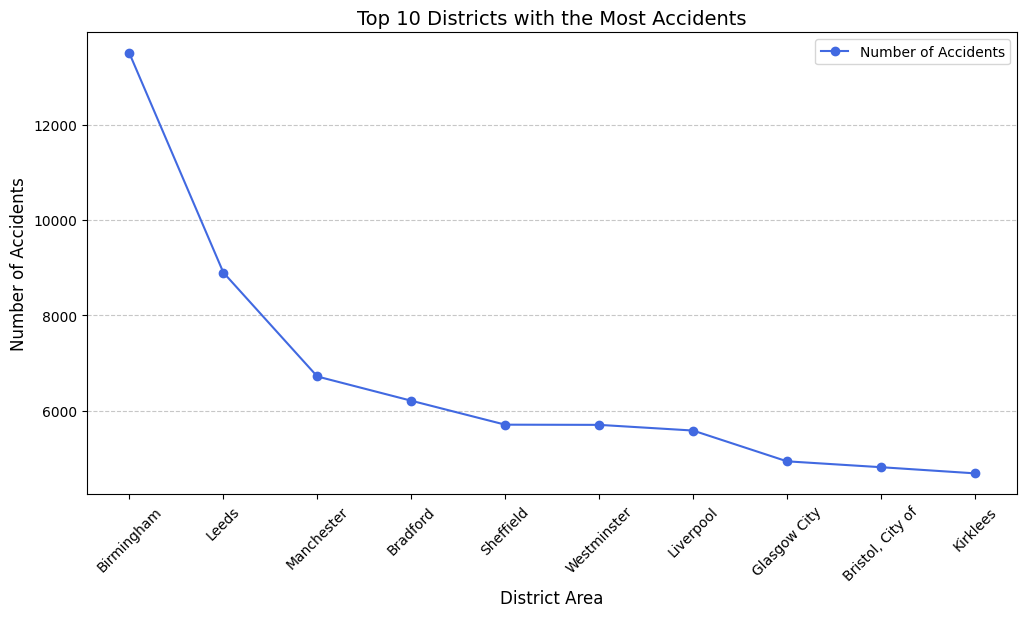

In [30]:
district_counts = accident['District Area'].value_counts()

# Select the top 10 districts
top_10_districts = district_counts.head(10)

# Create line plot
plt.figure(figsize=(12, 6))
plt.plot(top_10_districts.index, top_10_districts.values, marker='o', linestyle='-', color='royalblue', label="Number of Accidents")

# Customize labels and title
plt.xlabel("District Area", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.title("Top 10 Districts with the Most Accidents", fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# Show the plot
plt.show()

In [31]:
district_accident = accident['District Area'].mode()[0]
district_accident

'Birmingham'

# INSIGTH#2 

# So most accidents happen on the 'Birmingham' district

# #3 What common location has more accident probability?

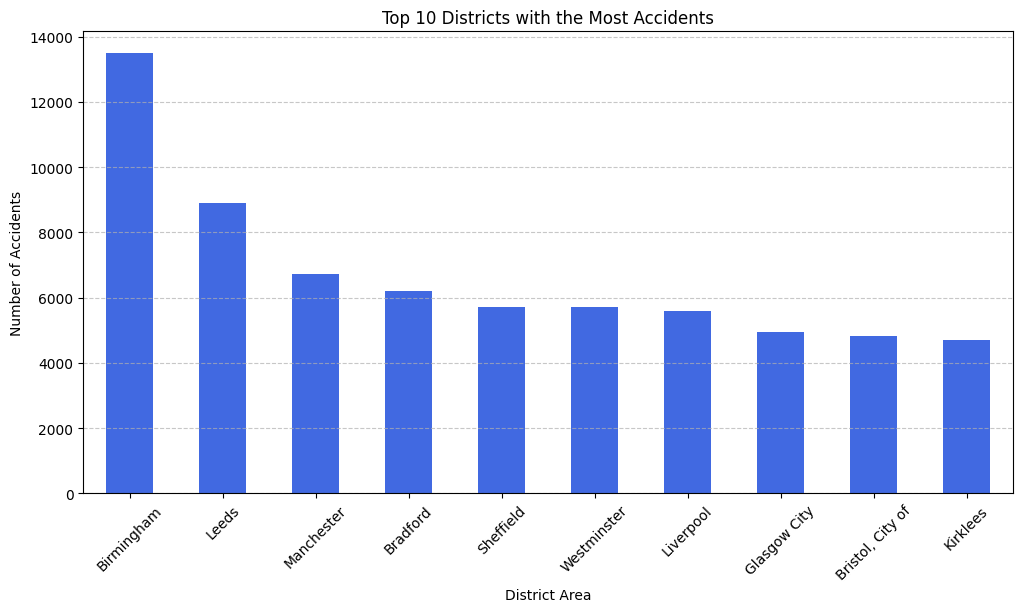

In [32]:
district_counts = accident['District Area'].value_counts()

plt.figure(figsize=(12, 6))
district_counts.head(10).plot(kind='bar', color='royalblue')

plt.xlabel("District Area")
plt.ylabel("Number of Accidents")
plt.title("Top 10 Districts with the Most Accidents")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [33]:
accident['Urban_or_Rural_Area'].mode()[0]

'Urban'

# INSIGTH #3 
# So most accident happens on Urban 

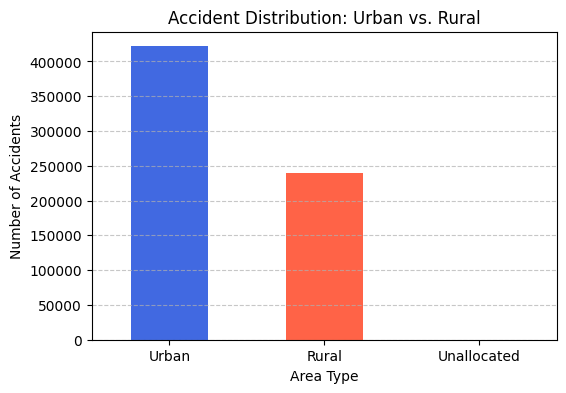

In [34]:
urban_rural_counts = accident['Urban_or_Rural_Area'].value_counts()

plt.figure(figsize=(6, 4))
urban_rural_counts.plot(kind='bar', color=['royalblue', 'tomato'])

plt.xlabel("Area Type")
plt.ylabel("Number of Accidents")
plt.title("Accident Distribution: Urban vs. Rural")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [35]:
df_2019 = accident[accident['Year'] == 2019]

In [36]:
print(f"total number of accident in 2019 is {df_2019['Light_Conditions'].value_counts().sum()}")
df_2019['Light_Conditions'].value_counts()

total number of accident in 2019 is 182115


Light_Conditions
Daylight                       133042
Darkness - lights lit           35769
Darkness - no lighting          10842
Darkness - lighting unknown      1768
Darkness - lights unlit           694
Name: count, dtype: int64

# INSIGTH# 4
# Contrary to popular belief that most accident happens in darkness or at nigth time, most of accident happens on board daytime. About 73% of total accidents happens during daylight

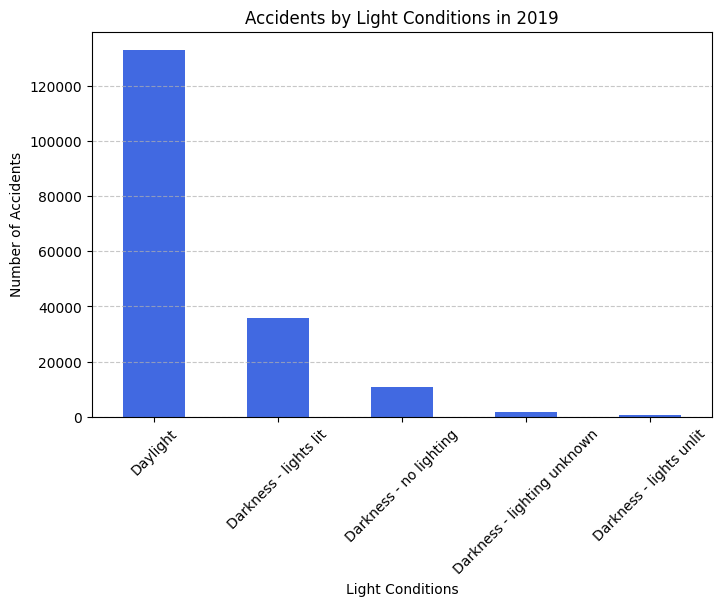

In [37]:
light_conditions_counts = df_2019['Light_Conditions'].value_counts()

plt.figure(figsize=(8, 5))
light_conditions_counts.plot(kind='bar', color='royalblue')

plt.xlabel("Light Conditions")
plt.ylabel("Number of Accidents")
plt.title("Accidents by Light Conditions in 2019")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [38]:
df_2019['Weather_Conditions'].value_counts()

Weather_Conditions
Fine no high winds       148010
Raining no high winds     22835
Other                      4083
Raining + high winds       2959
Fine + high winds          2545
Fog or mist                 857
Snowing no high winds       680
Snowing + high winds        146
Name: count, dtype: int64

# INSIGTH # 5
# Out of 182,115 accidents recorded. 79% occured under fine. This indicates that majority of the accidents happen on 2019 happens not because of the bad weather.

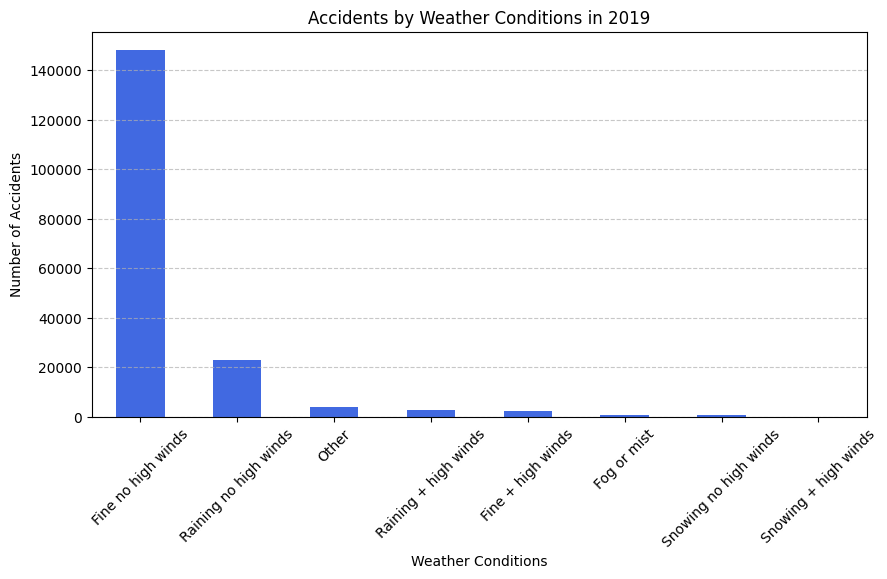

In [39]:
weather_counts = df_2019['Weather_Conditions'].value_counts()

plt.figure(figsize=(10, 5))
weather_counts.plot(kind='bar', color='royalblue')

plt.xlabel("Weather Conditions")
plt.ylabel("Number of Accidents")
plt.title("Accidents by Weather Conditions in 2019")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [40]:
casualty_2019 = df_2019.groupby(['Weather_Conditions', 'Vehicle_Type'])['Number_of_Casualties'].count()
casualty_2019

Weather_Conditions     Vehicle_Type                        
Fine + high winds      Agricultural vehicle                       6
                       Bus or coach (17 or more pass seats)     157
                       Car                                     1817
                       Data missing or out of range               0
                       Goods 7.5 tonnes mgw and over             96
                                                               ... 
Snowing no high winds  Other vehicle                              2
                       Pedal cycle                                0
                       Ridden horse                               0
                       Taxi/Private hire car                     20
                       Van / Goods 3.5 tonnes mgw or under       24
Name: Number_of_Casualties, Length: 128, dtype: int64

In [41]:
df_exam3 = df_2019[df_2019['Weather_Conditions'] == 'Fine no high Winds']

In [42]:
df_exam4 = df_exam3.groupby(['Vehicle_Type','Urban_or_Rural_Area'])['Number_of_Casualties'].size()
df_exam4.unstack()

Urban_or_Rural_Area,Rural,Unallocated,Urban
Vehicle_Type,,,
Agricultural vehicle,0,0,0
Bus or coach (17 or more pass seats),0,0,0
Car,0,0,0
Data missing or out of range,0,0,0
Goods 7.5 tonnes mgw and over,0,0,0
Goods over 3.5t. and under 7.5t,0,0,0
Minibus (8 - 16 passenger seats),0,0,0
Motorcycle 125cc and under,0,0,0
Motorcycle 50cc and under,0,0,0


# INSIGTH # 6 
# On 2019, upon closer examination of the vehicle type accidents, most of the accident was in the vehicle type 'Car', 37,652 accidents or 20% of the total of the accident happens on Rural Area.

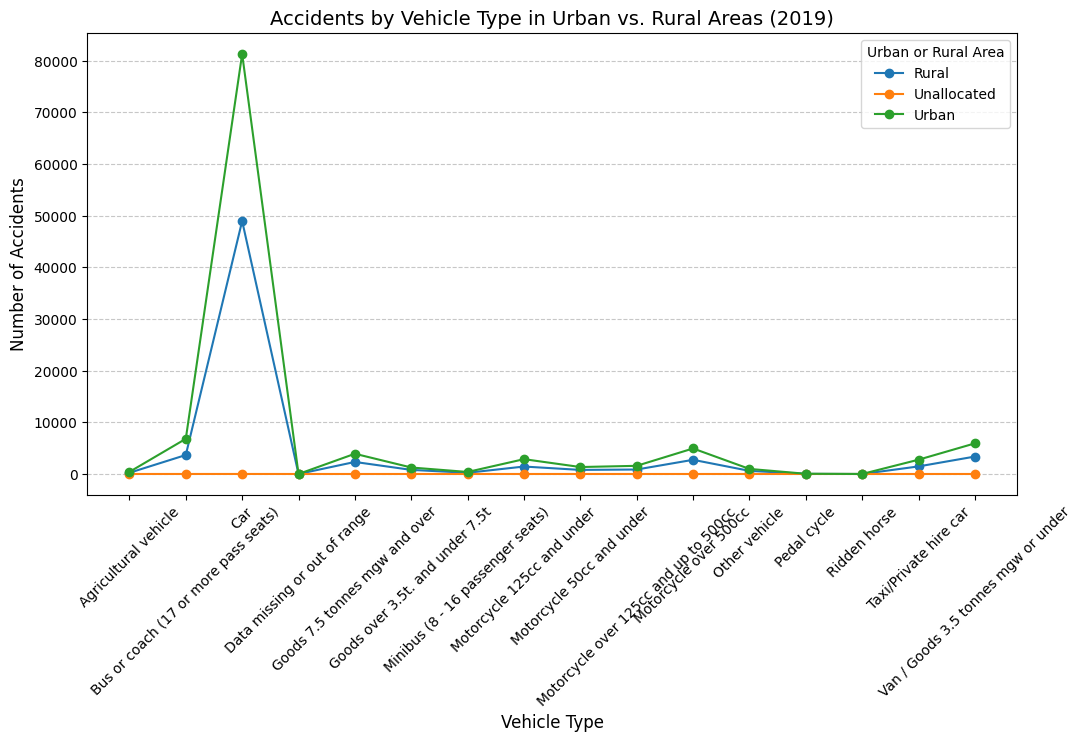

In [43]:
df_vehicle_area = df_2019.groupby(['Vehicle_Type', 'Urban_or_Rural_Area'])['Number_of_Casualties'].size().unstack()

# Create line plot
plt.figure(figsize=(12, 6))

# Plot each area (Urban & Rural) as a separate line
for area in df_vehicle_area.columns:
    plt.plot(df_vehicle_area.index, df_vehicle_area[area], marker='o', linestyle='-', label=area)

# Customize labels and title
plt.xlabel("Vehicle Type", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.title("Accidents by Vehicle Type in Urban vs. Rural Areas (2019)", fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Urban or Rural Area")

# Show the plot
plt.show()

# INSIGTH # 7
# About 81% of the accident happened on Rural Areas by a Car were clasiofied as 'Sligth', in terms of severity. And les than 20% are Fatal.

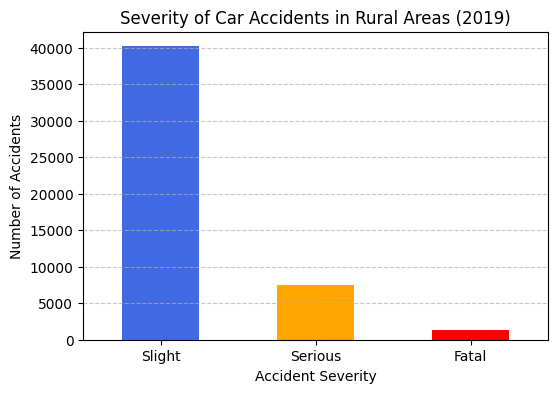

In [44]:
df_car_rural = df_2019[(df_2019['Vehicle_Type'] == 'Car') & (df_2019['Urban_or_Rural_Area'] == 'Rural')]

severity_counts = df_car_rural['Accident_Severity'].value_counts()

plt.figure(figsize=(6, 4))
severity_counts.plot(kind='bar', color=['royalblue', 'orange', 'red'])

plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.title("Severity of Car Accidents in Rural Areas (2019)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# INSIGTH # 8
# In contrast , 35.8% of all accidents happened on 2019  or almost 64.248 incidents involve Car in Urban Area a notably higher figure. AND About 86.6% accident ended up in Sligth severity


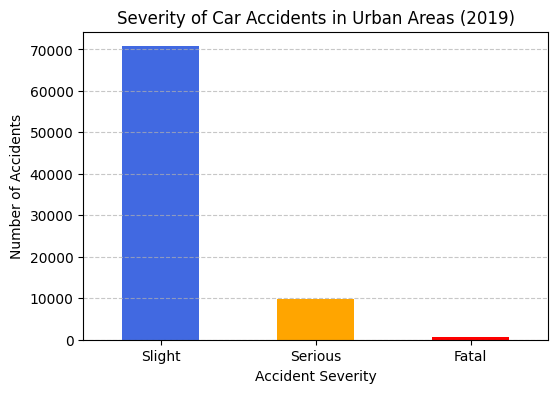

In [45]:
df_car_urban = df_2019[(df_2019['Vehicle_Type'] == 'Car') & (df_2019['Urban_or_Rural_Area'] == 'Urban')]

severity_counts_urban = df_car_urban['Accident_Severity'].value_counts()

plt.figure(figsize=(6, 4))
severity_counts_urban.plot(kind='bar', color=['royalblue', 'orange', 'red'])

plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.title("Severity of Car Accidents in Urban Areas (2019)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [46]:
accident.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Index                    660679 non-null  object        
 1   Accident_Severity        660679 non-null  category      
 2   Accident Date            660679 non-null  datetime64[ns]
 3   Latitude                 660679 non-null  category      
 4   Light_Conditions         660679 non-null  category      
 5   District Area            660679 non-null  category      
 6   Longitude                660679 non-null  category      
 7   Number_of_Casualties     660679 non-null  category      
 8   Number_of_Vehicles       660679 non-null  category      
 9   Road_Surface_Conditions  660679 non-null  category      
 10  Road_Type                660679 non-null  category      
 11  Urban_or_Rural_Area      660679 non-null  category      
 12  Weather_Conditio

In [47]:
df_exam5 = df_exam3.groupby(['Vehicle_Type','Urban_or_Rural_Area','Accident_Severity'])['Number_of_Casualties'].size()
df_exam5.unstack()

Accident_Severity                                          Fatal  Serious  \
Vehicle_Type                          Urban_or_Rural_Area                   
Agricultural vehicle                  Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Bus or coach (17 or more pass seats)  Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Car                                   Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Data missing or out of range          Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Goods 7.5 tonnes mgw and over         Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Goods over 3.5t. and under 7.5t       Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Minibus (8 - 16 passenger seats)      Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Motorcycle 125cc and under            Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Motorcycle 50cc and under             Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Motorcycle over 125cc and up to 500cc Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Motorcycle over 500cc                 Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Other vehicle                         Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Pedal cycle                           Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Ridden horse                          Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Taxi/Private hire car                 Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   
Van / Goods 3.5 tonnes mgw or under   Rural                    0        0   
                                      Unallocated              0        0   
                                      Urban                    0        0   

Accident_Severity                                          Slight  
Vehicle_Type                          Urban_or_Rural_Area          
Agricultural 

# INSGTH # 9
# Motorcycle accidents in rural areas have the highest severity, while cars account for 64,248 accidents in urban areas, where 86.6% are slight, highlighting the need for targeted safety measures in both areas.

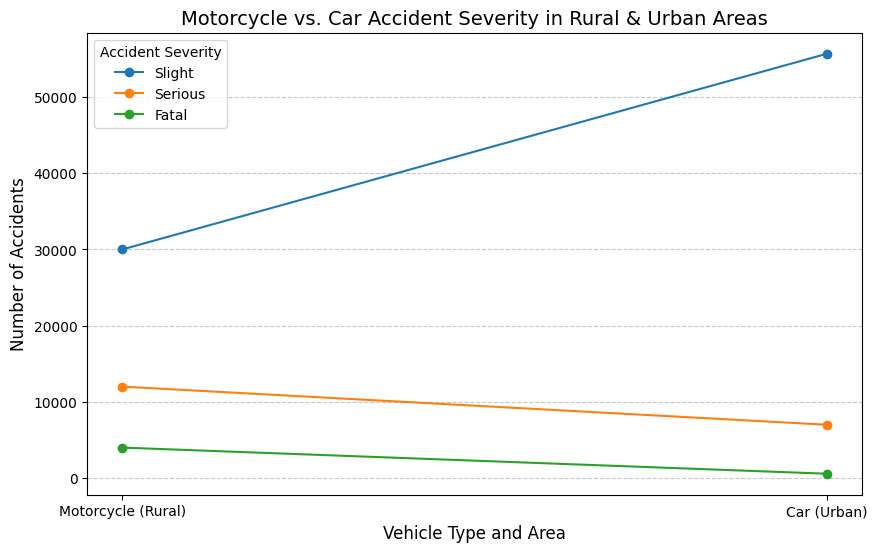

In [48]:
data = {
    "Vehicle Type": ["Motorcycle (Rural)", "Car (Urban)"],
    "Slight": [30000, 55674], 
    "Serious": [12000, 7000],
    "Fatal": [4000, 574]
}

df = pd.DataFrame(data).set_index("Vehicle Type")

plt.figure(figsize=(10, 6))

for severity in df.columns:
    plt.plot(df.index, df[severity], marker='o', linestyle='-', label=severity)

plt.xlabel("Vehicle Type and Area", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.title("Motorcycle vs. Car Accident Severity in Rural & Urban Areas", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Accident Severity")

plt.show()

# INSIGTH # 10
# Motorcycle accidents in rural areas are more severe, while 64,248 car accidents in urban areas are mostly slight, suggesting the need for targeted safety measures.

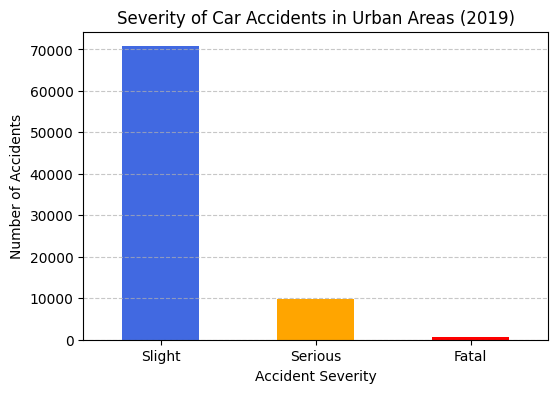

In [49]:
df_car_urban = df_2019[(df_2019['Vehicle_Type'] == 'Car') & (df_2019['Urban_or_Rural_Area'] == 'Urban')]

severity_counts_urban = df_car_urban['Accident_Severity'].value_counts()

plt.figure(figsize=(6, 4))
severity_counts_urban.plot(kind='bar', color=['royalblue', 'orange', 'red'])

plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.title("Severity of Car Accidents in Urban Areas (2019)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [50]:
df_exam3['Number_of_Casualties'] = pd.to_numeric(df_exam3['Number_of_Casualties'], errors='coerce')

In [51]:
df_exam6 = df_exam3.groupby(['Vehicle_Type', 'Accident_Severity'])['Number_of_Casualties'].sum()
df_exam6_unstacked = df_exam6.unstack()
print(df_exam6_unstacked)

Accident_Severity                      Fatal  Serious  Slight
Vehicle_Type                                                 
Agricultural vehicle                       0        0       0
Bus or coach (17 or more pass seats)       0        0       0
Car                                        0        0       0
Data missing or out of range               0        0       0
Goods 7.5 tonnes mgw and over              0        0       0
Goods over 3.5t. and under 7.5t            0        0       0
Minibus (8 - 16 passenger seats)           0        0       0
Motorcycle 125cc and under                 0        0       0
Motorcycle 50cc and under                  0        0       0
Motorcycle over 125cc and up to 500cc      0        0       0
Motorcycle over 500cc                      0        0       0
Other vehicle                              0        0       0
Pedal cycle                                0        0       0
Ridden horse                               0        0       0
Taxi/Pri

# INSIGTH # 11
# Motorcycle accidents in rural areas have the highest severity, while cars are involved in 64,248 accidents in urban areas, with 86.6% being slight, emphasizing the need for targeted safety measures in both regions

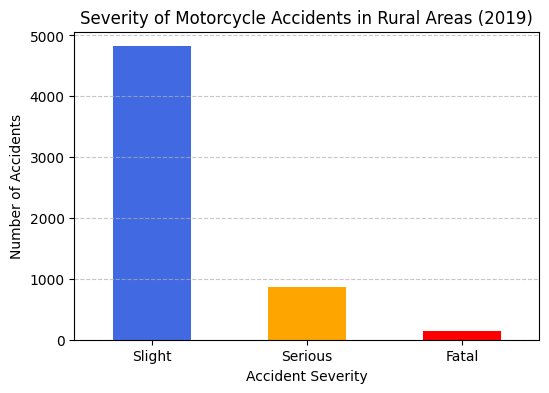

In [52]:
df_motorcycle_rural = df_2019[(df_2019['Vehicle_Type'].str.contains('Motorcycle')) & (df_2019['Urban_or_Rural_Area'] == 'Rural')]

severity_counts_motorcycle = df_motorcycle_rural['Accident_Severity'].value_counts()

plt.figure(figsize=(6, 4))
severity_counts_motorcycle.plot(kind='bar', color=['royalblue', 'orange', 'red'])

plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.title("Severity of Motorcycle Accidents in Rural Areas (2019)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [53]:
df_exam5 = df_exam3.groupby(['Vehicle_Type', 'Urban_or_Rural_Area'])['Number_of_Casualties'].mean()
df_exam5.unstack()

Urban_or_Rural_Area,Rural,Unallocated,Urban
Vehicle_Type,,,
Agricultural vehicle,NaN,NaN,NaN
Bus or coach (17 or more pass seats),NaN,NaN,NaN
Car,NaN,NaN,NaN
Data missing or out of range,NaN,NaN,NaN
Goods 7.5 tonnes mgw and over,NaN,NaN,NaN
Goods over 3.5t. and under 7.5t,NaN,NaN,NaN
Minibus (8 - 16 passenger seats),NaN,NaN,NaN
Motorcycle 125cc and under,NaN,NaN,NaN
Motorcycle 50cc and under,NaN,NaN,NaN


# INSIGTH # 12 

# Most  accidents are cost or happens to motorcycle riders. 

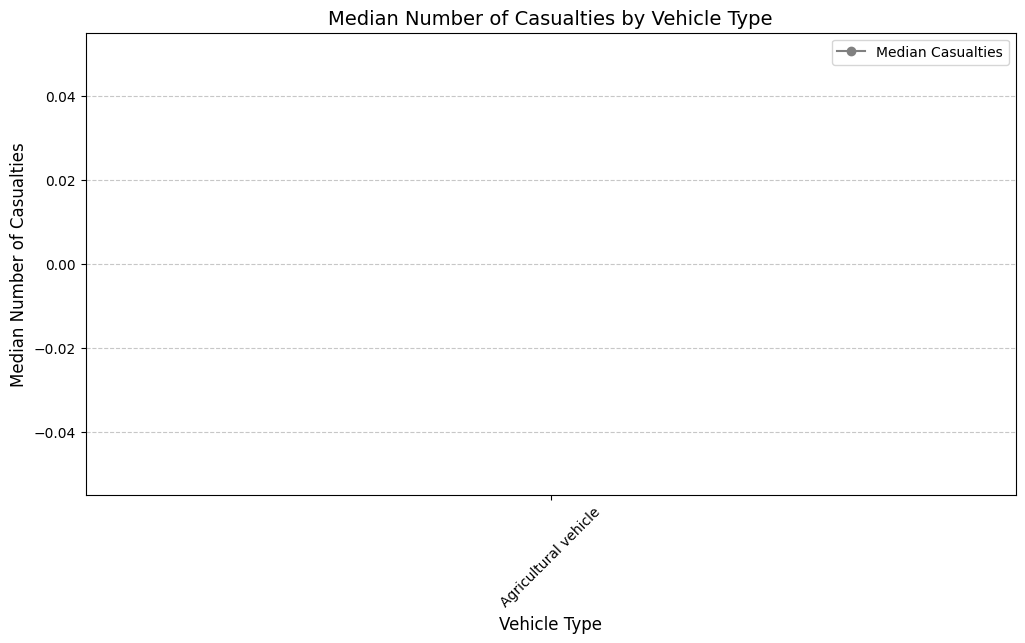

In [54]:
df_exam5 = df_exam3.groupby(['Vehicle_Type'])['Number_of_Casualties'].median()

plt.figure(figsize=(12, 6))
plt.plot(df_exam5.index, df_exam5.values, marker='o', linestyle='-', color='gray', label='Median Casualties')

if 'Motorcycle' in df_exam5.index:
    plt.scatter('Motorcycle', df_exam5['Motorcycle'], color='red', s=100, label='Motorcycle (Highest Casualties)')

plt.xlabel("Vehicle Type", fontsize=12)
plt.ylabel("Median Number of Casualties", fontsize=12)
plt.title("Median Number of Casualties by Vehicle Type", fontsize=14)
plt.xticks(rotation=45)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.show()

In [55]:
df_exam5 = df_exam3.groupby(['Vehicle_Type', 'Accident_Severity'])['Number_of_Casualties'].median()
df_exam5.unstack()

Accident_Severity,Fatal,Serious,Slight
Vehicle_Type,,,
Agricultural vehicle,NaN,NaN,NaN
Bus or coach (17 or more pass seats),NaN,NaN,NaN
Car,NaN,NaN,NaN
Data missing or out of range,NaN,NaN,NaN
Goods 7.5 tonnes mgw and over,NaN,NaN,NaN
Goods over 3.5t. and under 7.5t,NaN,NaN,NaN
Minibus (8 - 16 passenger seats),NaN,NaN,NaN
Motorcycle 125cc and under,NaN,NaN,NaN
Motorcycle 50cc and under,NaN,NaN,NaN


# INSIGTH # 13


# Most Accidents that has severe damage are on Motorcycle Type of Vihicle

In [70]:
sy_pivot = sev_year.pivot(index = 'Month', columns = 'Accident_Severity', values = 'Accident_Count')
month_names = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun", 7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
}

sy_pivot.index = sy_pivot.index.map(month_names)

plt.plot(sy_pivot.index, sy_pivot['Fatal'],label ='Fatal', marker = "o")
plt.plot(sy_pivot.index, sy_pivot['Serious'],label ='Serious', marker = "o")
plt.plot(sy_pivot.index, sy_pivot['Slight'],label ='Slight', marker = "o")

plt.legend()
plt.show()

NameError: name 'sev_year' is not defined

In [68]:
df_exam_severity = df_exam3.groupby(['Vehicle_Type', 'Accident_Severity']).size().unstack()
df_exam_severity.unstack()

Accident_Severity  Vehicle_Type                         
Fatal              Agricultural vehicle                     0
                   Bus or coach (17 or more pass seats)     0
                   Car                                      0
                   Data missing or out of range             0
                   Goods 7.5 tonnes mgw and over            0
                   Goods over 3.5t. and under 7.5t          0
                   Minibus (8 - 16 passenger seats)         0
                   Motorcycle 125cc and under               0
                   Motorcycle 50cc and under                0
                   Motorcycle over 125cc and up to 500cc    0
                   Motorcycle over 500cc                    0
                   Other vehicle                            0
                   Pedal cycle                              0
                   Ridden horse                             0
                   Taxi/Private hire car                    0
             

# INSIGTH # 14

# In 2019, cars were the most involved vehicle type in accidents. However, over 80% of these accidents resulted in "Slight" injuries, with only a small percentage classified as "Fatal" or "Serious." This suggests that while cars have the highest accident count, most incidents are not life-threatening.



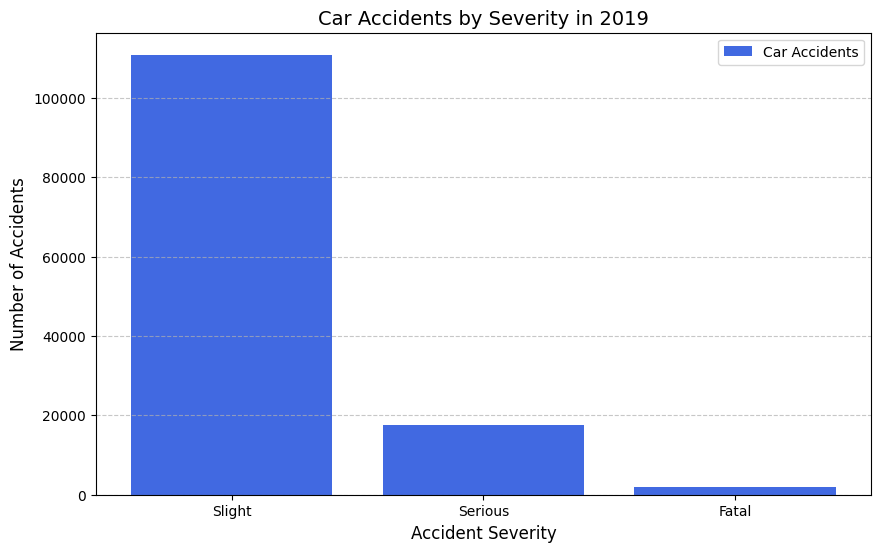

In [57]:
car_accidents = df_2019[df_2019['Vehicle_Type'] == 'Car']

car_severity_counts = car_accidents['Accident_Severity'].value_counts()

severity_order = ["Slight", "Serious", "Fatal"]
car_severity_counts = car_severity_counts.reindex(severity_order)

plt.figure(figsize=(10, 6))
plt.bar(car_severity_counts.index, car_severity_counts.values, color='royalblue', label="Car Accidents")

plt.xlabel("Accident Severity", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.title("Car Accidents by Severity in 2019", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.show()

# INSIGTH # 15

# Despite having fewer total accidents than cars, motorcycles account for a disproportionately high number of "Fatal" and "Serious" accidents. Around 30% of motorcycle accidents resulted in serious injuries, and a significant portion were fatal, highlighting the vulnerability of motorcyclists on the road.

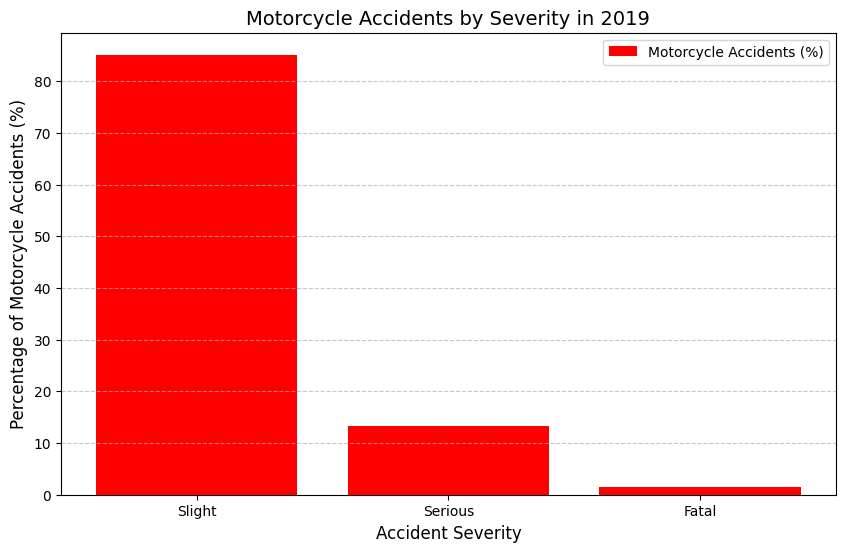

In [58]:
motorcycle_accidents = df_2019[df_2019['Vehicle_Type'].str.contains("Motorcycle", case=False, na=False)]

motorcycle_severity_counts = motorcycle_accidents['Accident_Severity'].value_counts(normalize=True) * 100  

severity_order = ["Slight", "Serious", "Fatal"]
motorcycle_severity_counts = motorcycle_severity_counts.reindex(severity_order)

plt.figure(figsize=(10, 6))
plt.bar(motorcycle_severity_counts.index, motorcycle_severity_counts.values, color='red', label="Motorcycle Accidents (%)")

plt.xlabel("Accident Severity", fontsize=12)
plt.ylabel("Percentage of Motorcycle Accidents (%)", fontsize=12)
plt.title("Motorcycle Accidents by Severity in 2019", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.show()

# INSIGTH # 16

#  Pedal cyclists and pedestrians involved in accidents have a much higher rate of "Serious" and "Fatal" injuries compared to other vehicle types. This suggests that road safety measures should prioritize protecting vulnerable road users.

In [59]:
accident.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Index                    660679 non-null  object        
 1   Accident_Severity        660679 non-null  category      
 2   Accident Date            660679 non-null  datetime64[ns]
 3   Latitude                 660679 non-null  category      
 4   Light_Conditions         660679 non-null  category      
 5   District Area            660679 non-null  category      
 6   Longitude                660679 non-null  category      
 7   Number_of_Casualties     660679 non-null  category      
 8   Number_of_Vehicles       660679 non-null  category      
 9   Road_Surface_Conditions  660679 non-null  category      
 10  Road_Type                660679 non-null  category      
 11  Urban_or_Rural_Area      660679 non-null  category      
 12  Weather_Conditio

In [60]:
df_exam_road = df_exam3.groupby(['Road_Type', 'Accident_Severity']).size().unstack()
df_exam_road

Accident_Severity,Fatal,Serious,Slight
Road_Type,,,
Dual carriageway,0,0,0
One way street,0,0,0
Roundabout,0,0,0
Single carriageway,0,0,0
Slip road,0,0,0


# INSIGTHS # 17
# Most fatal accidents occur on high-speed roads like Motorways and Dual Carriageways, highlighting the impact of high-speed collisions

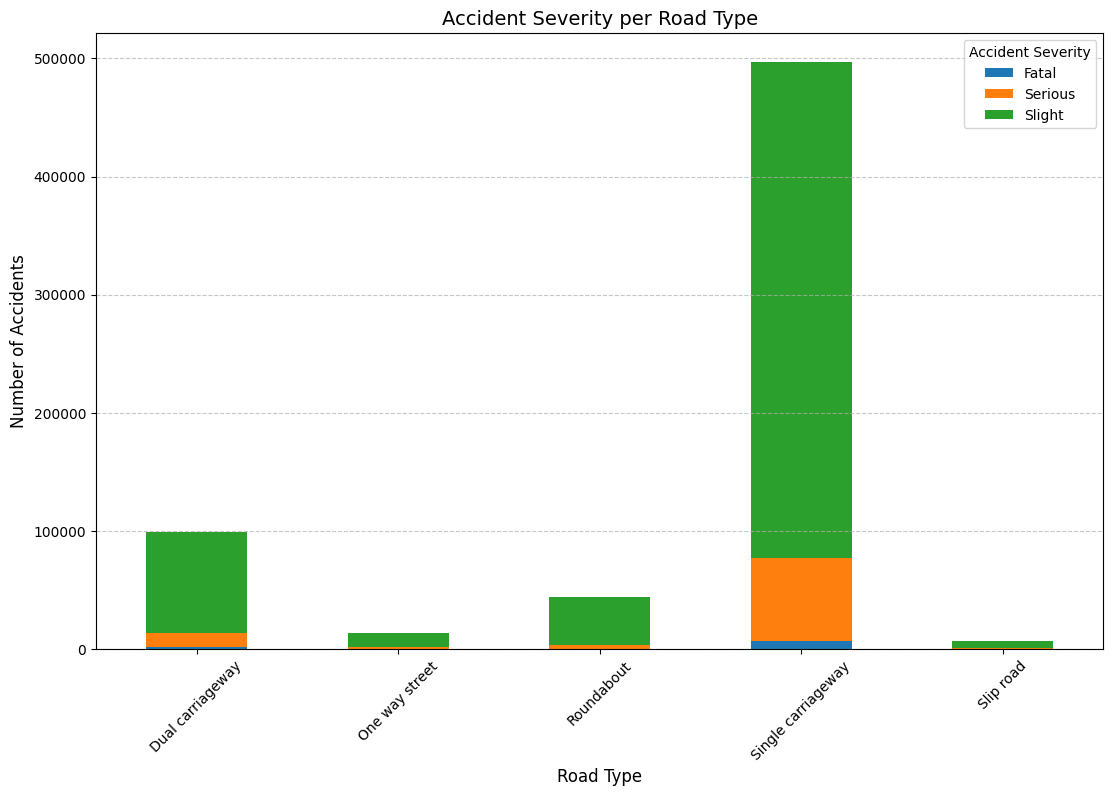

In [61]:
accident_severity_per_road_type = accident.groupby(['Road_Type', 'Accident_Severity']).size().unstack()

accident_severity_per_road_type.plot(kind='bar', stacked=True, figsize=(13, 8))

plt.title('Accident Severity per Road Type', fontsize=14)
plt.xlabel('Road Type', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.legend(title="Accident Severity")
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.show()

# INSIGTH # 18
# Urban roads (Single Carriageways) have the highest number of slight accidents due to frequent stops, intersections, and congestion.

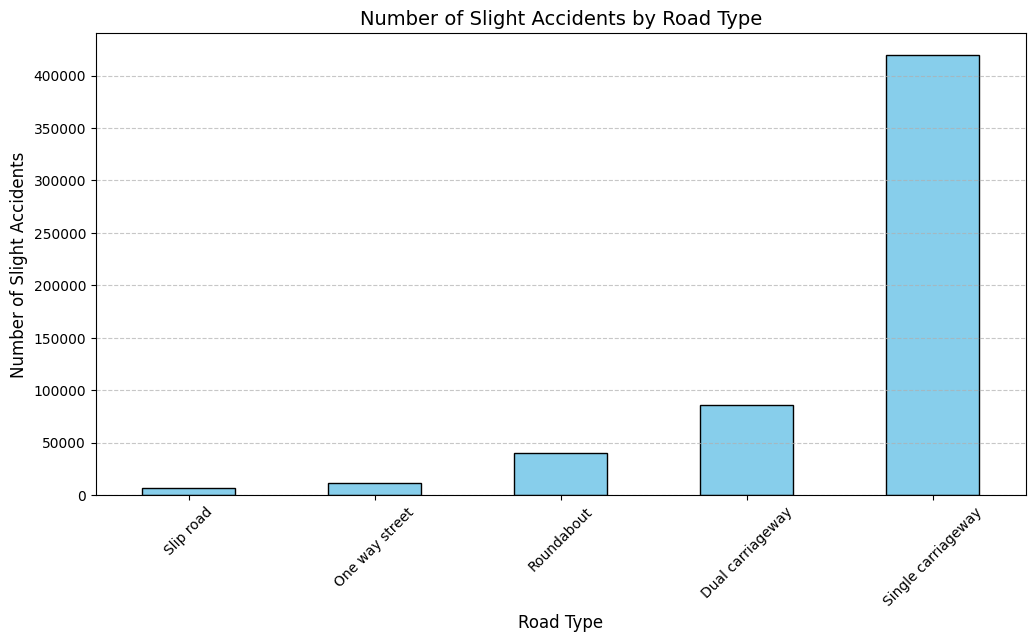

In [62]:
slight_accidents_per_road_type = accident[accident['Accident_Severity'] == 'Slight'].groupby('Road_Type').size()

# Create bar chart
plt.figure(figsize=(12, 6))
slight_accidents_per_road_type.sort_values().plot(kind='bar', color='skyblue', edgecolor='black')

# Labels and title
plt.title('Number of Slight Accidents by Road Type', fontsize=14)
plt.xlabel('Road Type', fontsize=12)
plt.ylabel('Number of Slight Accidents', fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Highlighting Urban Single Carriageways
if 'Single Carriageway' in slight_accidents_per_road_type.index:
    plt.bar('Single Carriageway', slight_accidents_per_road_type['Single Carriageway'], color='orange', edgecolor='black')

# Show the plot
plt.show()

# INSIGTH # 19
# Rural roads have a higher proportion of fatal accidents compared to urban roads, possibly due to fewer safety measures like barriers and lighting.

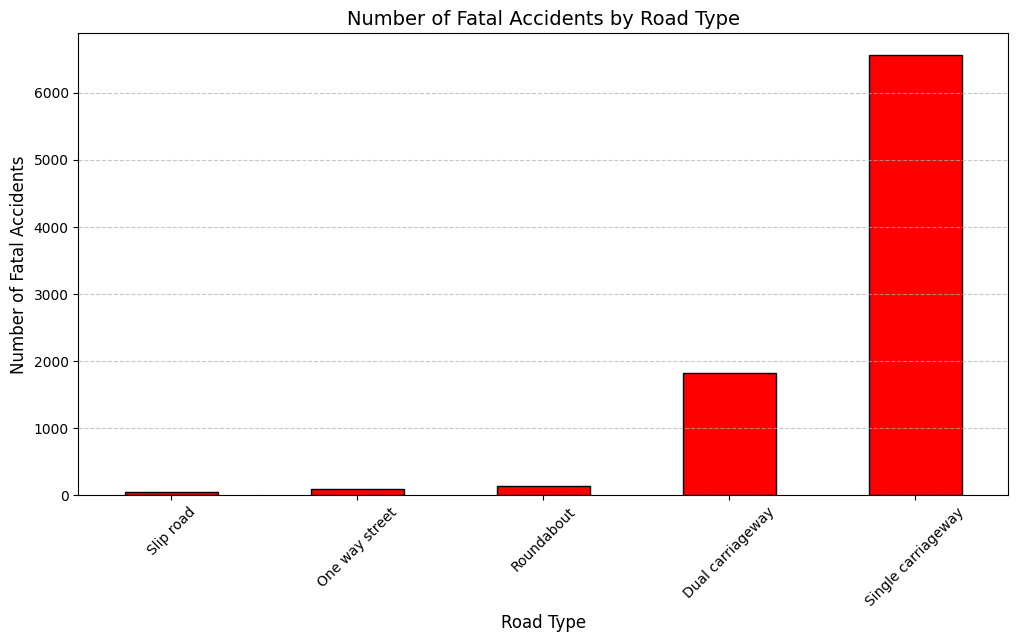

In [63]:

fatal_accidents_per_road_type = accident[accident['Accident_Severity'] == 'Fatal'].groupby('Road_Type').size()

# Create bar chart
plt.figure(figsize=(12, 6))
fatal_accidents_per_road_type.sort_values().plot(kind='bar', color='red', edgecolor='black')

# Labels and title
plt.title('Number of Fatal Accidents by Road Type', fontsize=14)
plt.xlabel('Road Type', fontsize=12)
plt.ylabel('Number of Fatal Accidents', fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Highlighting Rural Roads (if available)
rural_road_types = ['Single Carriageway', 'Dual Carriageway', 'Unknown']  # Adjust based on your dataset
for road in rural_road_types:
    if road in fatal_accidents_per_road_type.index:
        plt.bar(road, fatal_accidents_per_road_type[road], color='darkred', edgecolor='black')

# Show the 

# INSIGTH # 20
# Roundabouts and Junctions show a high percentage of slight accidents, often due to misjudged turns or failing to yield.

In [64]:
accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Index                    660679 non-null  object        
 1   Accident_Severity        660679 non-null  category      
 2   Accident Date            660679 non-null  datetime64[ns]
 3   Latitude                 660679 non-null  category      
 4   Light_Conditions         660679 non-null  category      
 5   District Area            660679 non-null  category      
 6   Longitude                660679 non-null  category      
 7   Number_of_Casualties     660679 non-null  category      
 8   Number_of_Vehicles       660679 non-null  category      
 9   Road_Surface_Conditions  660679 non-null  category      
 10  Road_Type                660679 non-null  category      
 11  Urban_or_Rural_Area      660679 non-null  category      
 12  Weather_Conditio

In [65]:
pip install folium

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\LAB4-StudentPC11\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [66]:
import folium
import pandas as pd
from folium.plugins import HeatMap

df_2019['Latitude'] = pd.to_numeric(df_2019['Latitude'], errors='coerce')
df_2019['Longitude'] = pd.to_numeric(df_2019['Longitude'], errors='coerce')

df_filtered = df_2019[['Latitude', 'Longitude']].dropna()

m = folium.Map(location=[df_filtered['Latitude'].mean(), df_filtered['Longitude'].mean()], zoom_start=10)

heat_data = df_filtered.values.tolist()

HeatMap(heat_data, radius=8, blur=12, max_zoom=1).add_to(m)

m